## Ejecutar este notebook en Google Colab

[![Run in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ricomelgozajjesus/monografia-armonica/blob/main/python-lab/notebooks/Notebook_IV_05_THD_y_espectro.ipynb)

# Notebook V.1 — Función descriptiva y primer armónico

Este notebook explora cómo distintas no linealidades estáticas transforman una entrada sinusoidal
y cómo la función descriptiva conserva únicamente la componente fundamental de la salida.

Se incluyen cuatro casos:
- relé ideal
- saturación simétrica
- zona muerta
- no linealidad cúbica

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = 2.0
omega = 1.0
T = 2*np.pi/omega
N = 4000
t = np.linspace(0, T, N, endpoint=False)
x = A*np.cos(omega*t)

M = 1.5
K = 1.0
E = 1.0
D = 0.8
alpha = 1.0
beta = 0.15

In [ ]:
def relay(x, M=1.0):
    y = np.where(x > 0, M, -M)
    y = np.where(x == 0, 0.0, y)
    return y

def symmetric_saturation(x, K=1.0, E=1.0):
    return np.where(np.abs(x) <= E, K*x, K*E*np.sign(x))

def dead_zone(x, K=1.0, D=1.0):
    y = np.zeros_like(x)
    mask_pos = x > D
    mask_neg = x < -D
    y[mask_pos] = K*(x[mask_pos] - D)
    y[mask_neg] = K*(x[mask_neg] + D)
    return y

def cubic_nl(x, alpha=1.0, beta=0.1):
    return alpha*x + beta*x**3

In [ ]:
def first_harmonic(y, t, omega):
    T = 2*np.pi/omega
    dt = t[1] - t[0]
    a1 = (2/T) * np.sum(y*np.cos(omega*t)) * dt
    b1 = (2/T) * np.sum(y*np.sin(omega*t)) * dt
    y1 = a1*np.cos(omega*t) + b1*np.sin(omega*t)
    return a1, b1, y1

def describing_function_numeric(y, A, t, omega):
    a1, b1, y1 = first_harmonic(y, t, omega)
    N = (a1 - 1j*b1)/A
    return N, a1, b1, y1

In [ ]:
cases = {
    "Relé ideal": relay(x, M=M),
    "Saturación simétrica": symmetric_saturation(x, K=K, E=E),
    "Zona muerta": dead_zone(x, K=K, D=D),
    "No linealidad cúbica": cubic_nl(x, alpha=alpha, beta=beta),
}

numeric_results = {}
for name, y in cases.items():
    Nnum, a1, b1, y1 = describing_function_numeric(y, A, t, omega)
    numeric_results[name] = {"y": y, "Nnum": Nnum, "a1": a1, "b1": b1, "y1": y1}

numeric_results

{'Relé ideal': {'y': array([1.5, 1.5, 1.5, ..., 1.5, 1.5, 1.5]),
  'Nnum': np.complex128(0.9549294622018232-0.00075j),
  'a1': np.float64(1.9098589244036464),
  'b1': np.float64(0.0015),
  'y1': array([1.90985892, 1.90985892, 1.90985421, ..., 1.90983065, 1.90984479,
         1.90985421])},
 'Saturación simétrica': {'y': array([1., 1., 1., ..., 1., 1., 1.]),
  'Nnum': np.complex128(0.6089977432186497-1.4210854715202004e-17j),
  'a1': np.float64(1.2179954864372995),
  'b1': np.float64(2.842170943040401e-17),
  'y1': array([1.21799549, 1.21799398, 1.21798948, ..., 1.21798196, 1.21798948,
         1.21799398])},
 'Zona muerta': {'y': array([1.2       , 1.19999753, 1.19999013, ..., 1.19997779, 1.19999013,
         1.19999753]),
  'Nnum': np.complex128(0.5046314908986188-7.105427357601002e-18j),
  'a1': np.float64(1.0092629817972376),
  'b1': np.float64(1.4210854715202004e-17),
  'y1': array([1.00926298, 1.00926174, 1.009258  , ..., 1.00925178, 1.009258  ,
         1.00926174])},
 'No lineal

In [ ]:
def N_relay(A, M):
    return 4*M/(np.pi*A)

def N_saturation(A, K, E):
    A = float(A)
    if A <= E:
        return K
    return (2*K/np.pi) * (np.arcsin(E/A) + (E/A)*np.sqrt(1 - (E/A)**2))

def N_dead_zone(A, K, D):
    A = float(A)
    if A <= D:
        return 0.0
    return (2*K/np.pi) * (
        np.pi/2 - np.arcsin(D/A) - (D/A)*np.sqrt(1 - (D/A)**2)
    )

def N_cubic(A, alpha, beta):
    return alpha + 0.75*beta*A**2

analytic_results = {
    "Relé ideal": N_relay(A, M),
    "Saturación simétrica": N_saturation(A, K, E),
    "Zona muerta": N_dead_zone(A, K, D),
    "No linealidad cúbica": N_cubic(A, alpha, beta),
}

print(f"A = {A:.3f}")
print("-"*72)
for name in cases:
    Nnum = numeric_results[name]["Nnum"]
    Nth = analytic_results[name]
    print(f"{name:24s}  N_num = {Nnum.real: .6f} {Nnum.imag:+.6f}j   N_teo = {Nth: .6f}")

A = 2.000
------------------------------------------------------------------------
Relé ideal                N_num =  0.954929 -0.000750j   N_teo =  0.954930
Saturación simétrica      N_num =  0.608998 -0.000000j   N_teo =  0.608998
Zona muerta               N_num =  0.504631 -0.000000j   N_teo =  0.504632
No linealidad cúbica      N_num =  1.450000 +0.000000j   N_teo =  1.450000


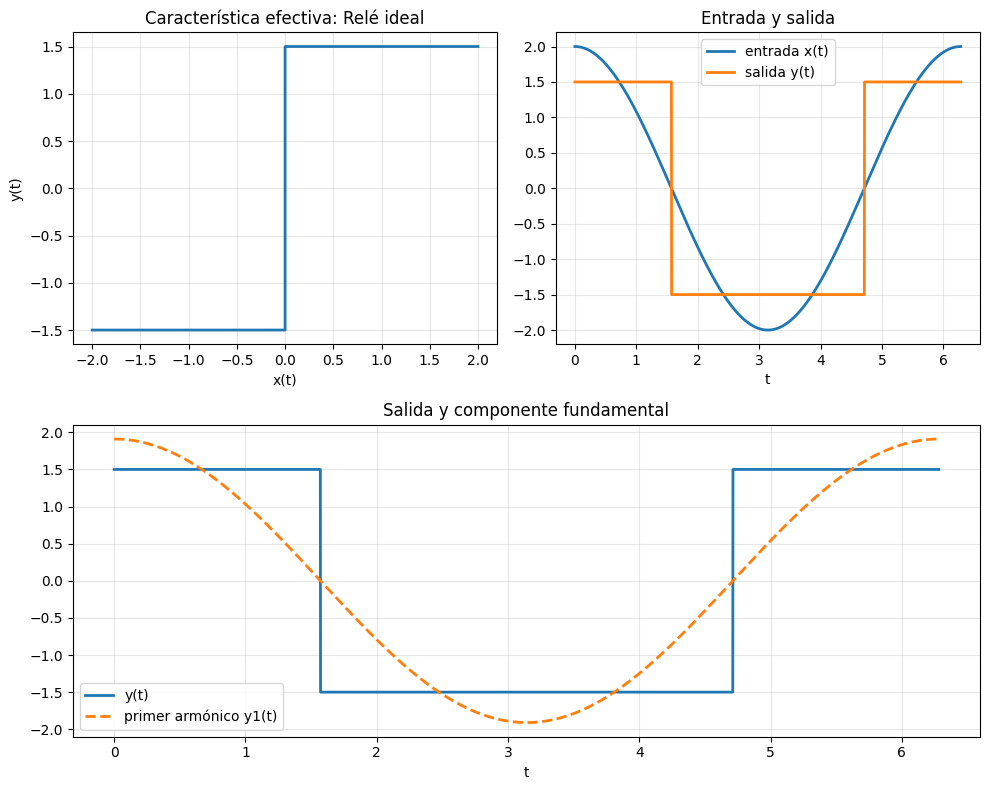

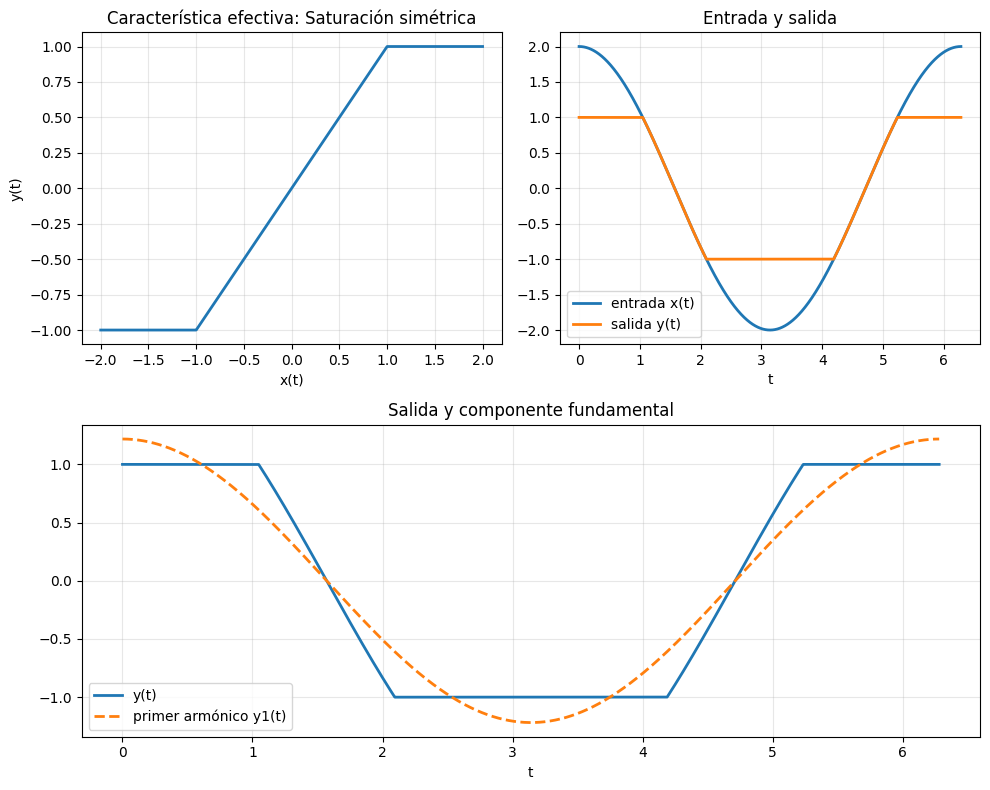

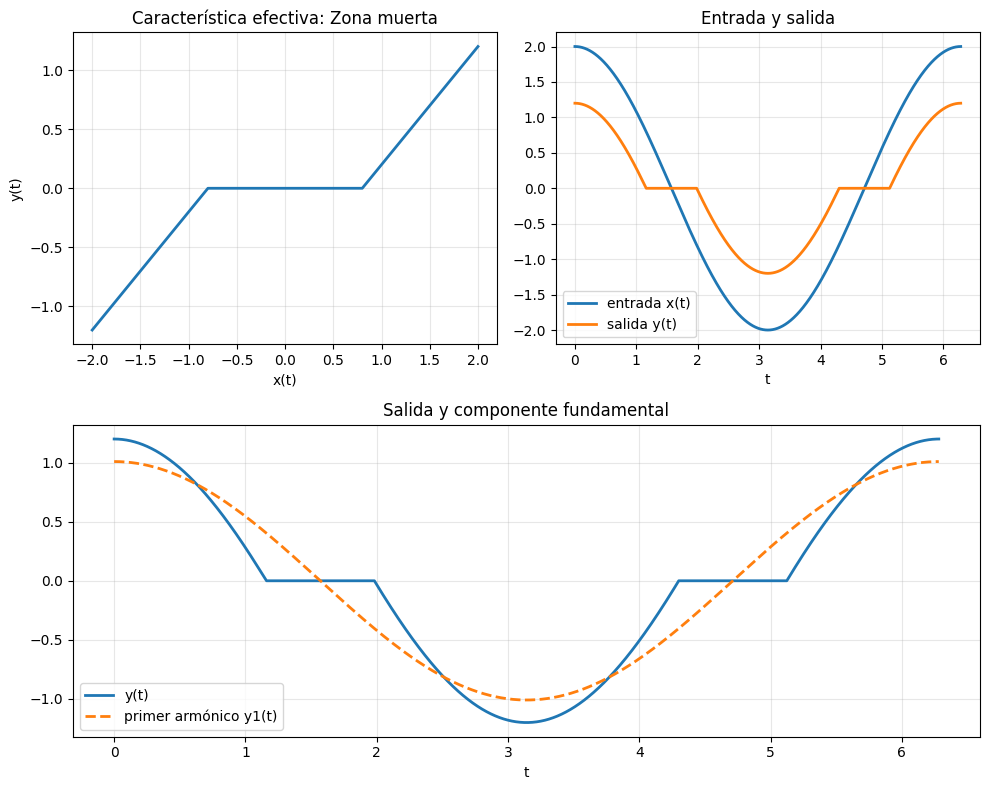

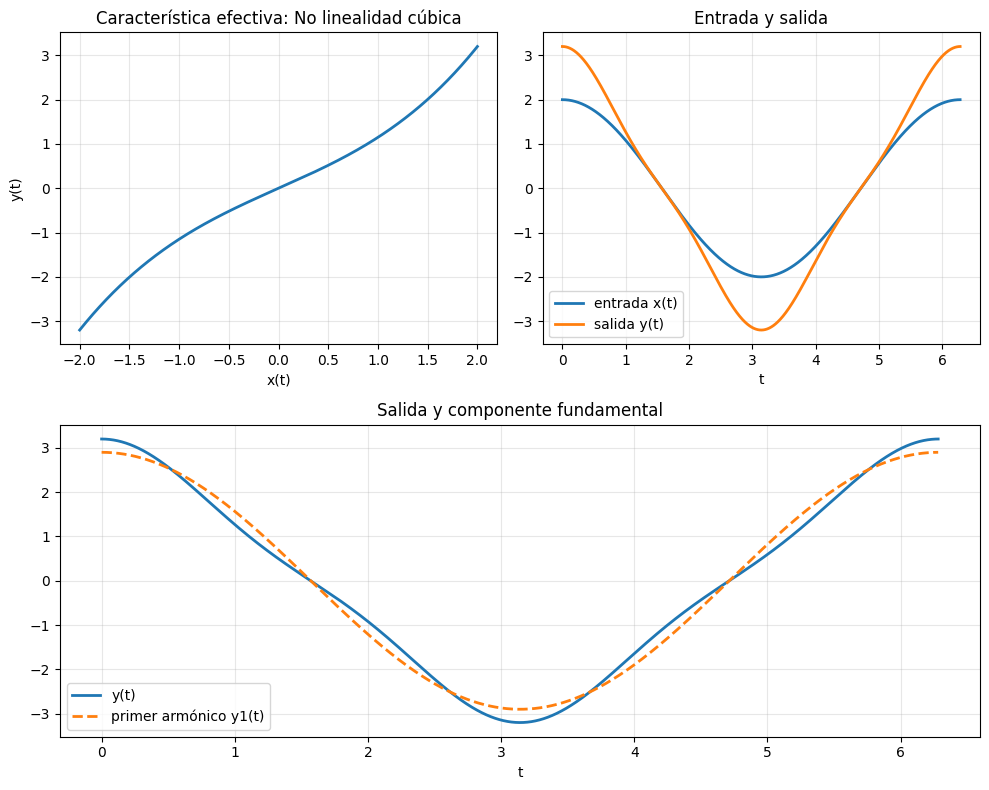

In [ ]:
def plot_case(name, x, y, y1):
    plt.figure(figsize=(10, 8))

    ax1 = plt.subplot(2,2,1)
    idx = np.argsort(x)
    ax1.plot(x[idx], y[idx], linewidth=2)
    ax1.set_title(f"Característica efectiva: {name}")
    ax1.set_xlabel("x(t)")
    ax1.set_ylabel("y(t)")
    ax1.grid(True, alpha=0.3)

    ax2 = plt.subplot(2,2,2)
    ax2.plot(t, x, label="entrada x(t)", linewidth=2)
    ax2.plot(t, y, label="salida y(t)", linewidth=2)
    ax2.set_title("Entrada y salida")
    ax2.set_xlabel("t")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3 = plt.subplot(2,1,2)
    ax3.plot(t, y, label="y(t)", linewidth=2)
    ax3.plot(t, y1, '--', label="primer armónico y1(t)", linewidth=2)
    ax3.set_title("Salida y componente fundamental")
    ax3.set_xlabel("t")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()

for name, data in numeric_results.items():
    plot_case(name, x, data["y"], data["y1"])

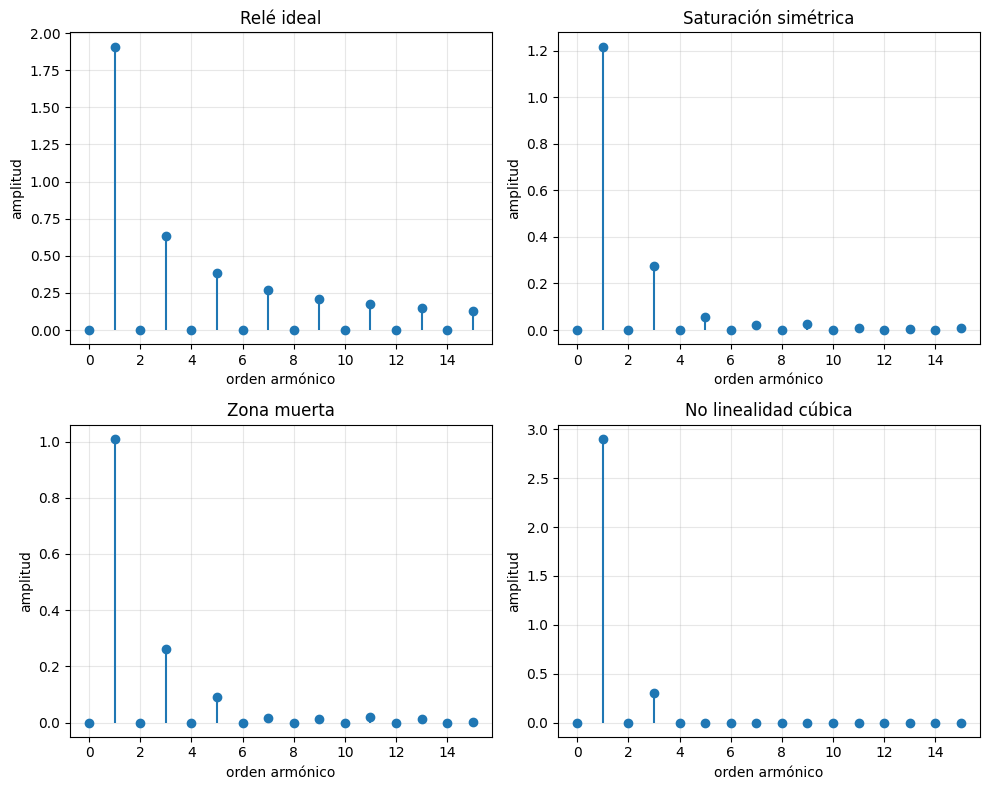

In [ ]:
def one_sided_spectrum(y, t, omega):
    dt = t[1]-t[0]
    Y = np.fft.rfft(y)/len(y)
    freqs_hz = np.fft.rfftfreq(len(y), d=dt)
    fundamental_hz = omega/(2*np.pi)
    harmonic_order = freqs_hz/fundamental_hz
    amp = 2*np.abs(Y)
    amp[0] = np.abs(Y[0])
    return harmonic_order, amp

plt.figure(figsize=(10, 8))
for i, (name, data) in enumerate(numeric_results.items(), start=1):
    ax = plt.subplot(2,2,i)
    h, amp = one_sided_spectrum(data["y"], t, omega)
    mask = h <= 15
    markerline, stemlines, baseline = ax.stem(h[mask], amp[mask], basefmt=" ")
    ax.set_title(name)
    ax.set_xlabel("orden armónico")
    ax.set_ylabel("amplitud")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Sugerencias de exploración

1. Cambia la amplitud `A` y observa cómo cambia `N(A)`.
2. En saturación y zona muerta, compara el caso `A<E` o `A<D` con el caso de entrada mayor al umbral.
3. En la no linealidad cúbica, cambia el signo de `beta` y observa el efecto sobre la ganancia efectiva.
4. Compara la señal completa `y(t)` con su primer armónico `y1(t)` para entender qué retiene y qué descarta la función descriptiva.